# Robinhood App Review Analysis
Customer Feedback Intelligence Pipeline Project- BU CS 506

## 1. Packages

In [4]:
!pip install app-store-web-scraper
!pip install google-play-scraper
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=87f99bbae7fbcad69f1ccda9392d5d63a64577226264459209815882fce3623b
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [5]:
# imports
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from app_store_web_scraper import AppStoreEntry
from google_play_scraper import reviews, Sort
from langdetect import detect, LangDetectException
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


## 2. Data Collection

### Google Play Reviews Scraping

In [6]:
# Google Play store scraping
result, _ = reviews(
    'com.robinhood.android',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=5000
)

gplay_reviews = []
for r in result:
    gplay_reviews.append({
        'review': r['content'],
        'rating': r['score'],
        'date': r['at'],
        'title': r['reviewId'],
        'country': 'google_play'
    })

gplay_df = pd.DataFrame(gplay_reviews)
print(f"Google Play reviews scraped: {len(gplay_df)}")

Google Play reviews scraped: 5000


### App Store Reviews Scraping

In [7]:
# App Store Reviews
all_reviews = []

# try catch to handle error when the reviews are unorganised data
for country in ['us', 'gb']:
    app = AppStoreEntry(app_id=938003185, country=country)
    count = 0
    try:
        for review in app.reviews():
            all_reviews.append({
                'review': review.content,
                'rating': review.rating,
                'date': review.date,
                'title': review.title,
                'country': country
            })
            count += 1
            if count >= 1000: #the apple api has a limit of 500 reviews (50 pages per country)
                break
    except TypeError:
        print(f"{country}: stopped early due to parsing error")
    print(f"{country}: scraped {count} reviews")
countries = ['us', 'gb']

app_store_df = pd.DataFrame(all_reviews)
app_store_df = app_store_df.drop_duplicates(subset='review')
print(f"App Store: {len(app_store_df)}")

# convert to pandas data frame and csv file
app_store_df.to_csv("robinhoods_reviews_app_store.csv")

us: scraped 500 reviews
gb: stopped early due to parsing error
gb: scraped 100 reviews
App Store: 599


### Combine Sources

In [8]:
def get_sentiment(rating): #for labeling sentiment based on rating
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

combined_df = pd.concat([app_store_df, gplay_df], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset='review')
combined_df = combined_df.dropna(subset=['review'])
combined_df['sentiment'] = combined_df['rating'].apply(get_sentiment)
combined_df['source'] = combined_df['country'].apply(lambda x: 'App Store' if x in ['us', 'gb'] else 'Google Play')
combined_df = combined_df.reset_index(drop=True)

# discard too short (20 then 30)
combined_df['review_length'] = combined_df['review'].apply(len)
combined_df = combined_df[combined_df['review_length'] > 30]

print(f"App Store: {len(app_store_df)}")
print(f"Google Play: {len(gplay_df)}")
print(f"Total combined reviews: {len(combined_df)}")
combined_df['rating'].value_counts().sort_index()

App Store: 599
Google Play: 5000
Total combined reviews: 4004


,count
rating,
1,1985
2,291
3,287
4,345
5,1096


## 3. EDA

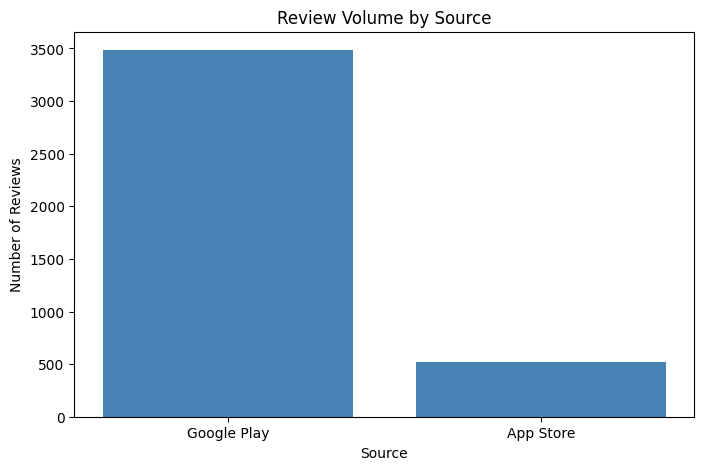

In [13]:
# Review volume by source
source_counts = combined_df['source'].value_counts().rename('count').to_frame()
all_sources = pd.DataFrame({'source': ['Google Play', 'App Store']})
merged_counts = all_sources.set_index('source').merge(source_counts, left_index=True, right_index=True, how='left').fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(merged_counts.index, merged_counts['count'], color='steelblue')
plt.xlabel('Source')
plt.ylabel('Number of Reviews')
plt.title('Review Volume by Source')
plt.show()

Note: the distribution of the data is heavily skewed toward 1 stars and 5 stars fewer 2s, 3s and 4s. People either didn't like the app or they really liked it, basically few in betweens.

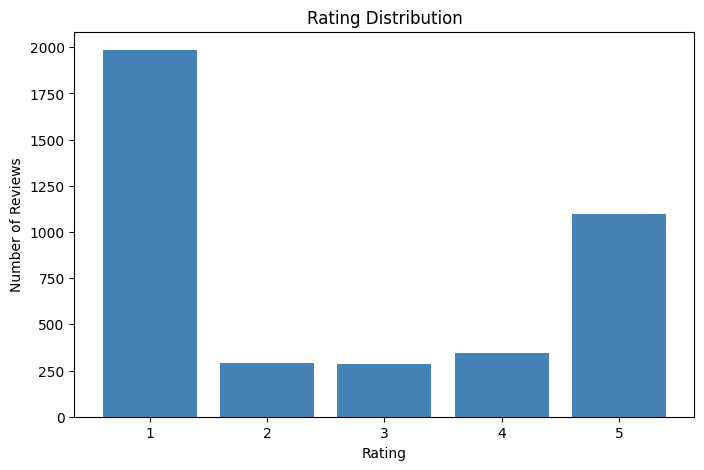

In [9]:
# counting the number of ratings for each type of rating
freq = combined_df['rating'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(freq.index, freq.values, color='steelblue')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating Distribution')
plt.show()

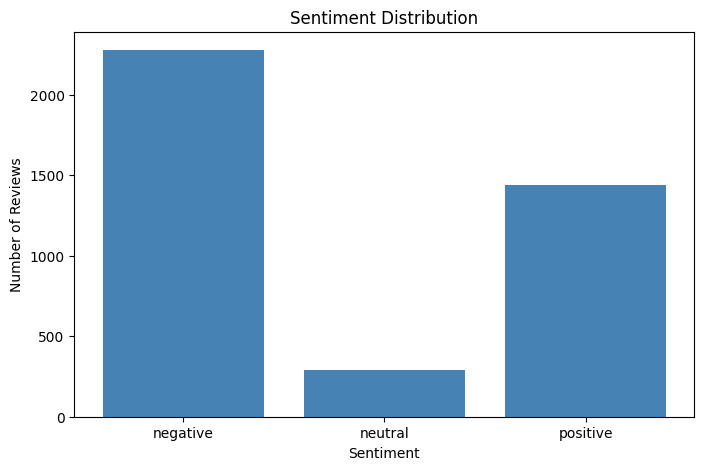

In [10]:
freq = combined_df['sentiment'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(freq.index, freq.values, color='steelblue')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Distribution')
plt.show()

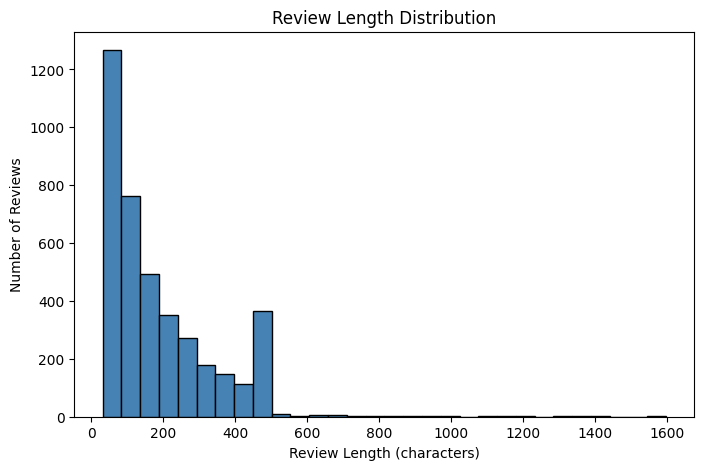

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(combined_df['review_length'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.title('Review Length Distribution')
plt.show()

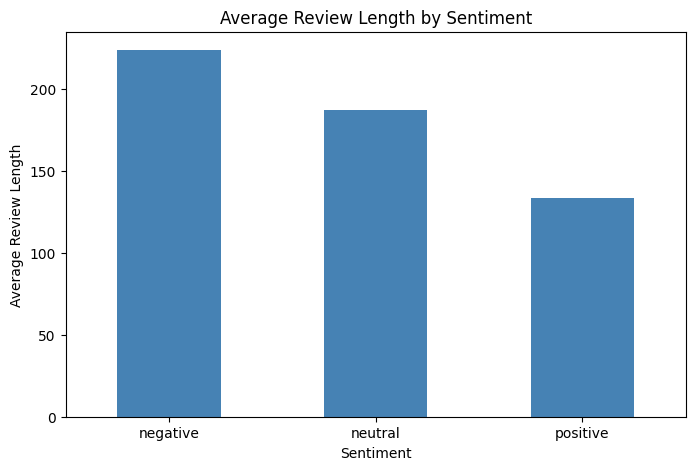

In [12]:
combined_df.groupby('sentiment')['review_length'].mean().plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.xlabel('Sentiment')
plt.ylabel('Average Review Length')
plt.title('Average Review Length by Sentiment')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_6310/1721647885.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')


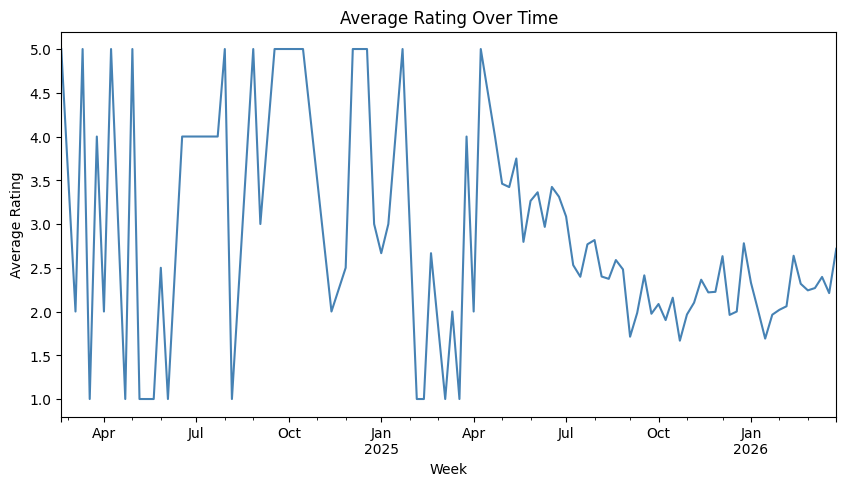

In [14]:
combined_df['date'] = pd.to_datetime(combined_df['date'], utc=True)
combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time')
plt.show()

- The spikes are misleading because a single 5-star review in a week with no other reviews gives an average of 5.0, which looks dramatic but means nothing.


/tmp/ipykernel_6310/2381793897.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].count().plot(figsize=(10, 5), color='steelblue')


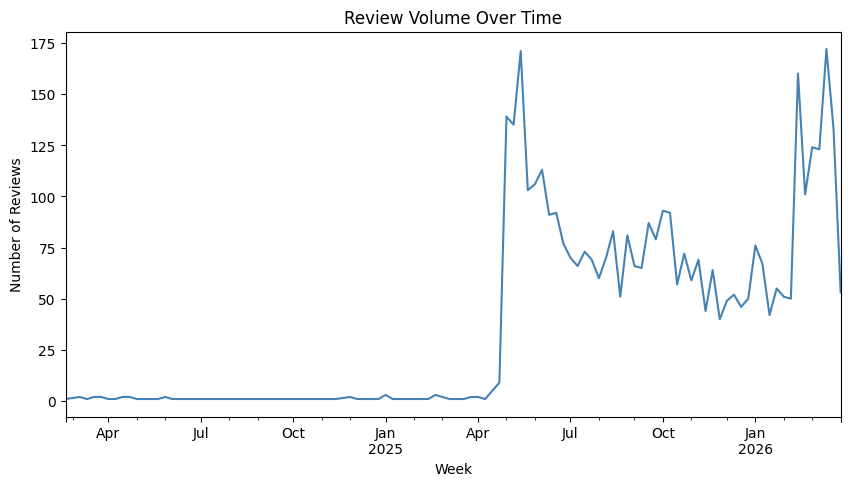

In [15]:
combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].count().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Number of Reviews')
plt.title('Review Volume Over Time')
plt.show()

/tmp/ipykernel_6310/235398449.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gplay_only.groupby(gplay_only['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')


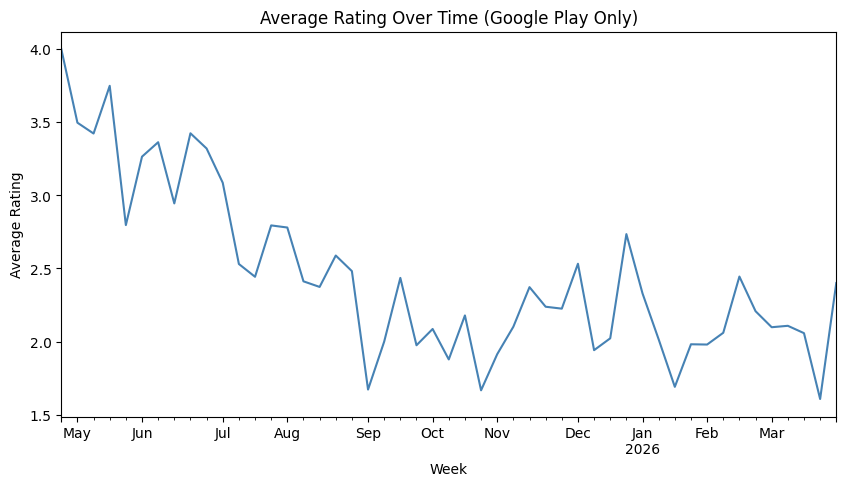

In [16]:
# Average rating over time (Google Play only)
# More reliable - consistent volume of 80-250 reviews per week
gplay_only = combined_df[combined_df['source'] == 'Google Play']
gplay_only.groupby(gplay_only['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time (Google Play Only)')
plt.show()

## 4. Data Cleaning

In [17]:
# Remove the non-English reviews

# Short reviews kept since langdetect seems unreliable on very short

def is_english(text):
    try:
        if len(str(text)) < 20:
            return True
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

before = len(combined_df)
combined_df = combined_df[combined_df['review'].apply(is_english)].reset_index(drop=True)
print(f'Removed {before - len(combined_df)} non-English reviews')
print(f'Remaining: {len(combined_df)}')

Removed 44 non-English reviews
Remaining: 3960


In [18]:
# realized i needed to clean the data- terrible clusters with raw reviews, all numbers showing up
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

combined_df['clean_review'] = combined_df['review'].apply(clean_text)
combined_df = combined_df.reset_index(drop=True)
combined_df.to_csv('robinhood_reviews_cleaned.csv', index=False)
print(f'Cleaned dataset saved: {len(combined_df)} reviews')

combined_df.head(3)[['review', 'clean_review']]

Cleaned dataset saved: 3960 reviews


,review,clean_review
0,When it takes me 20 clicks to get out of your ...,when it takes me clicks to get out of your ad...
1,Everywhere you do something there’s a fee.\n\n...,everywhere you do something theres a fee\n\n\n...
2,"Great trading experience, easy to use, secure,...",great trading experience easy to use secure an...


## 5. Feature Extraction (TF-IDF)

In [32]:
# domain specific stop words too common in this dataset to be useful
# added after analyzing first cluster output which had noise words like 'robinhood' etc

reviews_stops = {
    'app', 'use', 'get', 'like', 'one', 'would', 'could',
    'really', 'also', 'even', 'still', 'ive', 'dont', 'cant',
    'good', 'great', 'bad', 'nice', 'love', 'hate',
    'going', 'got', 'make', 'made', 'take', 'taking',
    'robinhood'
    }

stop_words = list(ENGLISH_STOP_WORDS.union(reviews_stops))

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=stop_words,
    min_df=20,          # minimum number of documents that a term must appear in to be considered a term
    max_df=0.85,        # if a term appears in more than that percent of documents, it will not be considered
    ngram_range=(1, 2),
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True,  # replaces raw term frequency with 1 + log (freq)
    max_features=2000
)

X = tfidf.fit_transform(combined_df['clean_review'])
print(f'TF-IDF shape: {X.shape}')
print(f'features: {len(tfidf.get_feature_names_out())}')

TF-IDF shape: (3960, 606)
features: 606


## 6. Dimensionality Reduction (LSA)

In [33]:
# tackling the hd data and kmeans issue
svd = TruncatedSVD(n_components=20, n_iter=15, random_state=42)


lsa = make_pipeline(svd, Normalizer(copy=False))
X_reduced = lsa.fit_transform(X)

print(f'matrix shape: {X_reduced.shape}')

matrix shape: (3960, 20)


## 7. Clustering with K-means

k=3: silhouette=0.0951
k=4: silhouette=0.1058
k=5: silhouette=0.1193
k=6: silhouette=0.1283
k=7: silhouette=0.1314
k=8: silhouette=0.1444
k=9: silhouette=0.1513
k=10: silhouette=0.1592

Best k: 10


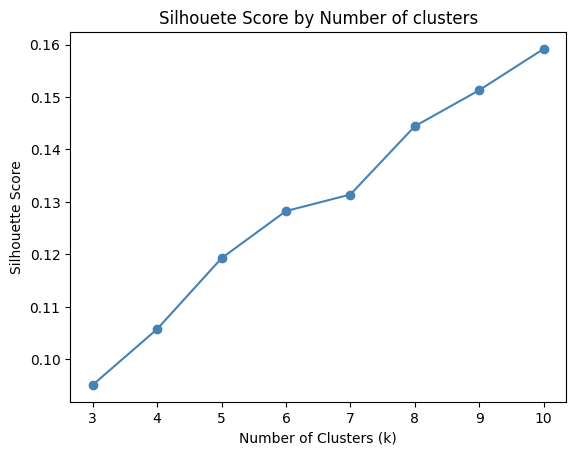

In [34]:
# silhouette score to find the best k
sil_scores = {}
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels, random_state=42)
    sil_scores[k] = score
    print(f'k={k}: silhouette={score:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k: {best_k}')

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouete Score by Number of clusters')
plt.show()

the silhouette score marginally favored k=10, ill go with k=5 because of the project goal of identifying the top 5 complaint themes, and because the score differences between k values were minimal anyways.

K-Means makes spherical clusters but text data is high-dimensional, 1000 feature, and sparse, which explains the low scores.

In [35]:
# Final K-means with k=5
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_arr = km_final.fit_predict(X_reduced)
combined_df['cluster'] = cluster_labels_arr

# top terms per cluster
feature_names = tfidf.get_feature_names_out()
for i in range(5):
    top_indices = km_final.cluster_centers_[i].argsort()[-10:][::-1]
    top_terms = [feature_names[j] for j in top_indices]
    print(f'Cluster {i}: {top_terms}')

Cluster 0: ['ability', 'access account', 'access', 'actual', 'added', 'account', 'advanced', 'ads', 'allowed', 'ago']
Cluster 1: ['ability', 'added', 'account', 'add', 'ago', 'ads', 'adding', 'actual', 'absolutely', 'access']
Cluster 2: ['ability', 'adding', 'actually', 'advanced', 'ads', 'allow', 'add', 'accounts', 'able', 'agent']
Cluster 3: ['able', 'ability', 'absolutely', 'added', 'adding', 'advanced', 'account', 'access account', 'access', 'allow']
Cluster 4: ['ability', 'absolutely', 'accounts', 'agent', 'adding', 'allow', 'advanced', 'ago', 'ads', 'access account']


In [23]:
def print_sample_reviews(df, cluster_num, n=5):
    samples = df[df['cluster'] == cluster_num]['review'].sample(n)
    for i, review in enumerate(samples):
        print(f"{i+1}. {review}\n")

In [24]:
print_sample_reviews(combined_df, 2)

1. Please add two features! 1. A month to month return section. 2. For options, include a Return on investment(ROI)

2. good love legend but you need more indicators like trading view then you would be #1

3. Just give up, there is no hope for you or for anyone. This company found a way to screw struggling people over with unforgiving customer support hours. Good luck getting a human person agent when it actually counts. I’m not saying that other platforms are better or worse because there is no good platform because there is no good economy. Best of luck everyone. I’m exhausted. Don’t worry I won’t off myself, I’m not built that way, and I’m just a little bitter sometimes…

4. The absolute best options trading platform in the uk!

I’m giving it 4/5 starts for the time being because we cannot buy any ETFs. 

I understand EU/UK regs on buying US etfs but we at the minimum need either options trading on US ETFs (IBKR allows this, you’re allowed to trade derivatives on US ETFs) or prefera

first attempt realized cleaning with regex is needed because produced numbers in the clusters that isnt necesary then. i analyzed and decided to keep adding to the stop words:
```
Cluster 0: ['robinhood', 'money', 'trading', 'good', 'stock', 'stocks', 'like', 'market', 'best', 'time']
Cluster 1: ['great', 'great app', 'app', 'easy', 'investing', 'platform', 'works', 'app great', 'investment', 'trading']
Cluster 2: ['account', 'cant', 'get', 'customer', 'phone', 'money', 'support', 'email', 'service', 'customer service']
Cluster 3: ['app', 'update', 'open', 'use', 'love', 'keeps', 'robinhood', 'love app', 'good', 'fix']
Cluster 4: ['easy', 'easy use', 'use', 'app easy', 'app', 'great', 'good', 'love', 'use great', 'great app']
```

In [25]:
# experimenting with ngram range

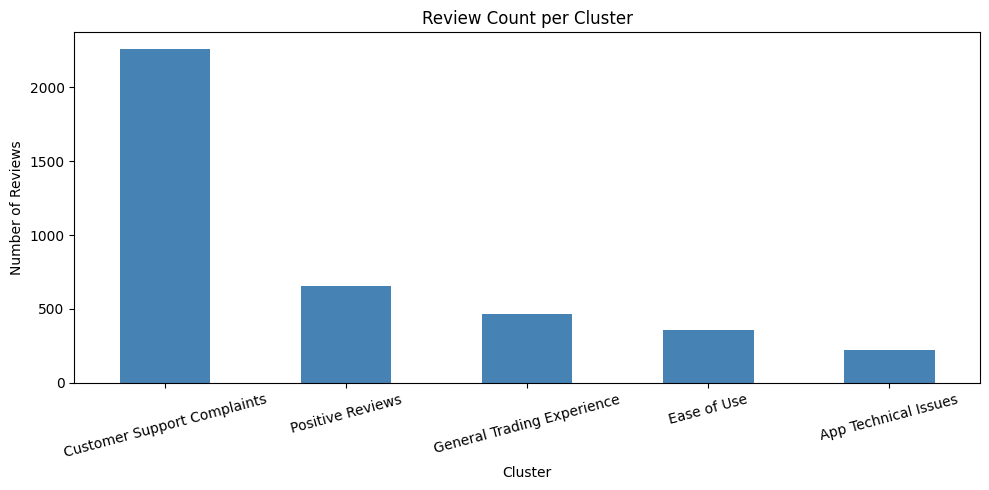

In [26]:
# Manually label clusters based on top terms
cluster_label_map = {
    0: 'General Trading Experience',
    1: 'Positive Reviews', #more general
    2: 'Customer Support Complaints',
    3: 'App Technical Issues',
    4: 'Ease of Use'
}
combined_df['cluster_label'] = combined_df['cluster'].map(cluster_label_map)

# Cluster frequency chart
combined_df['cluster_label'].value_counts().plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.title('Review Count per Cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Sentiment Classification

In [28]:
# Train-test split of data
X_train, X_test, y_train, y_test = train_test_split(
    X, combined_df['sentiment'], test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (3168, 606), Test: (792, 606)


In [29]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print('Logistic Regression:')
print(classification_report(y_test, lr_preds))

# Confusion matrix
cm = confusion_matrix(y_test, lr_preds, labels=['negative', 'neutral', 'positive'])
cm_df = pd.DataFrame(cm,
    index=['True: negative', 'True: neutral', 'True: positive'],
    columns=['Predicted: negative', 'Predicted: neutral', 'Predicted: positive']
)
print('Confusion Matrix:')
cm_df

Logistic Regression:
              precision    recall  f1-score   support

    negative       0.80      0.91      0.85       461
     neutral       0.00      0.00      0.00        59
    positive       0.79      0.79      0.79       272

    accuracy                           0.80       792
   macro avg       0.53      0.57      0.55       792
weighted avg       0.74      0.80      0.77       792

Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Predicted: negative,Predicted: neutral,Predicted: positive
True: negative,418,0,43
True: neutral,46,0,13
True: positive,56,0,216


In [30]:
print(f'LR Accuracy: {accuracy_score(y_test, lr_preds):.3f}')


LR Accuracy: 0.801
